# House Price Prediction using Linear Regression

**Name:** Dhibiksha V S  
**Track:** Data Analytics  
**Organization:** OASIS Infobyte  
**Level:** Level 2 – Task 1

## Objective

To build a Linear Regression model to predict house prices based on relevant housing features.

In [3]:
import os

print(os.getcwd())

C:\Users\DHIBIKSHA V S\Downloads


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\DHIBIKSHA V S\Downloads\house-prices-advanced-regression-techniques\train.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 1460
Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset Overview

The dataset contains information about residential properties and their sale prices. Before building the prediction model, the dataset is examined to understand its structure, data types, and missing values.

In [6]:
# Display dataset information

print("Dataset Information:")
df.info()

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Missing Value Analysis

Missing values are checked to identify columns that require preprocessing before training the Linear Regression model.

In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Columns with missing values:")
display(missing_values[missing_values > 0].sort_values(ascending=False))

Columns with missing values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Feature Selection

The `SalePrice` column is selected as the target variable because it represents the house sale price we want to predict.

A small set of relevant numerical features is selected as input for the Linear Regression model.

In [8]:
# Select features and target

features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'FullBath',
    'YearBuilt'
]

X = df[features]
y = df['SalePrice']

print("Selected Features:")
print(features)

print("\nTarget Variable: SalePrice")

display(X.head())

Selected Features:
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

Target Variable: SalePrice


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt
0,7,1710,2,856,2,2003
1,6,1262,2,1262,2,1976
2,7,1786,2,920,2,2001
3,7,1717,3,756,1,1915
4,8,2198,3,1145,2,2000


## Handling Missing Values

The selected numerical features are checked for missing values. Since Linear Regression cannot work directly with missing values, missing numerical values are replaced using the median of each feature.

In [9]:
# Check missing values in selected features

print("Missing values before handling:")
print(X.isnull().sum())

# Fill missing values with the median
X = X.fillna(X.median())

print("\nMissing values after handling:")
print(X.isnull().sum())

Missing values before handling:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
YearBuilt      0
dtype: int64

Missing values after handling:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
YearBuilt      0
dtype: int64


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the Linear Regression model, while the testing data is used to evaluate its performance on unseen data.

In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


## Linear Regression Model

A Linear Regression model is trained using the selected housing features. The model learns the relationship between the property features and the sale price from the training data.

In [11]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## Model Prediction

The trained Linear Regression model is used to predict house prices for the test dataset. These predictions will be compared with the actual sale prices to evaluate the model.

In [12]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Predicted Prices:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predicted Prices:
[143345.09052504 295831.75475447 122206.49630347 177280.62009441
 287975.46943113  56886.42980661 210437.89139038 173697.4206396
  56184.60646274 130980.92806046]


## Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

These metrics help measure the accuracy of the predictions and how well the model explains the variation in house prices.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Evaluation Results
------------------------------
Mean Absolute Error (MAE): 25319.86
Mean Squared Error (MSE): 1576962754.88
Root Mean Squared Error (RMSE): 39710.99
R² Score: 0.7944


## Actual vs Predicted House Prices

The actual sale prices are compared with the prices predicted by the Linear Regression model. A scatter plot is used to visualize how closely the predictions match the actual values.

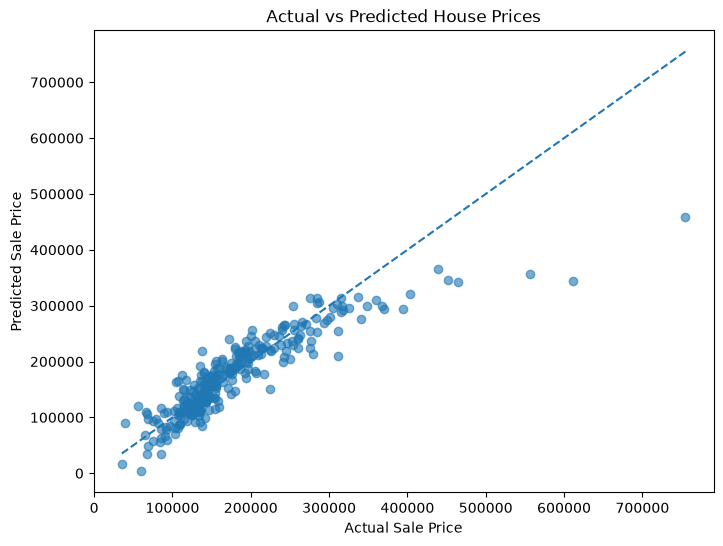

In [15]:
# Plot actual vs predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Feature Coefficients

The Linear Regression coefficients show how each selected feature influences the predicted house price. A positive coefficient indicates that an increase in the feature is associated with an increase in predicted price, while a negative coefficient indicates the opposite relationship.

In [16]:
# Display feature coefficients

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient
0,OverallQual,20507.201279
2,GarageCars,15329.408539
5,YearBuilt,350.911672
1,GrLivArea,51.993398
3,TotalBsmtSF,24.475400
4,FullBath,-5421.210340


## Feature Coefficient Visualization

The coefficients of the selected features are visualized to make it easier to compare their influence on the predicted house prices.

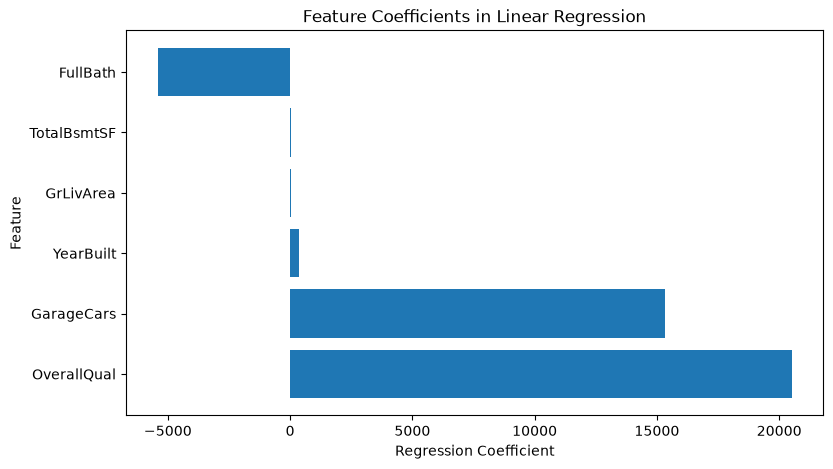

In [17]:
# Plot feature coefficients

plt.figure(figsize=(9, 5))

plt.barh(coefficients['Feature'], coefficients['Coefficient'])

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients in Linear Regression")

plt.show()

## Prediction Comparison

A comparison table is created to examine the actual sale prices alongside the prices predicted by the Linear Regression model.

In [18]:
# Create a comparison table

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison['Difference'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

display(comparison.head(10))

,Actual Price,Predicted Price,Difference
0,154500,143345.090525,11154.909475
1,325000,295831.754754,29168.245246
2,115000,122206.496303,-7206.496303
3,159000,177280.620094,-18280.620094
4,315500,287975.469431,27524.530569
5,75500,56886.429807,18613.570193
6,311500,210437.891390,101062.108610
7,146000,173697.420640,-27697.420640
8,84500,56184.606463,28315.393537
9,135500,130980.928060,4519.071940


## Model Performance

The distribution of prediction errors is visualized to understand how closely the model's predictions match the actual house prices.

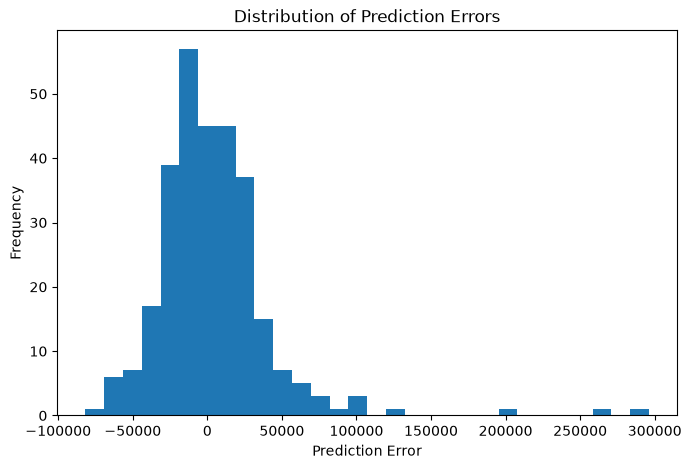

In [19]:
# Calculate prediction errors

errors = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

## Model Summary

The Linear Regression model was trained using selected housing features and evaluated on unseen test data. The evaluation metrics and visualizations provide an overall understanding of the model's predictive performance.

In [20]:
# Display final model performance

print("Final Model Performance")
print("=" * 30)
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

print("\nModel training and evaluation completed successfully.")

Final Model Performance
MAE  : 25,319.86
MSE  : 1,576,962,754.88
RMSE : 39,710.99
R²   : 0.7944

Model training and evaluation completed successfully.


## Save the Trained Model

The trained Linear Regression model is saved as a file so that it can be reused for future predictions without retraining the model.

In [21]:
import joblib

# Save the trained model
joblib.dump(model, "house_price_linear_regression_model.pkl")

print("Model saved successfully!")
print("File: house_price_linear_regression_model.pkl")

Model saved successfully!
File: house_price_linear_regression_model.pkl


## Sample House Price Prediction

The trained Linear Regression model is tested with sample property data to demonstrate how it can predict the sale price of a house.

In [22]:
# Create sample house data

sample_house = pd.DataFrame({
    'OverallQual': [7],
    'GrLivArea': [2000],
    'GarageCars': [2],
    'TotalBsmtSF': [1000],
    'FullBath': [2],
    'YearBuilt': [2005]
})

# Predict the house price
predicted_price = model.predict(sample_house)

print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))

Predicted House Price: $235,512.58


## Conclusion

A Linear Regression model was successfully developed to predict house sale prices using selected housing features.

The dataset was explored and preprocessed before training the model. The model was evaluated using MAE, MSE, RMSE, and R² Score, and its predictions were compared with actual sale prices through visualizations.

This project provided practical experience in data preprocessing, feature selection, model training, prediction, and evaluation using Python and Scikit-learn.

## Final Verification

The final dataset, model performance, and generated model file are verified to ensure that all major project components were completed successfully.

In [23]:
print("FINAL PROJECT VERIFICATION")
print("=" * 35)

print("Dataset shape:", df.shape)
print("Selected features:", len(features))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel Performance:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

print("\nModel file: house_price_linear_regression_model.pkl")
print("\nProject completed successfully!")

FINAL PROJECT VERIFICATION
Dataset shape: (1460, 81)
Selected features: 6
Training samples: 1168
Testing samples: 292

Model Performance:
MAE : 25319.86
RMSE: 39710.99
R² Score: 0.7944

Model file: house_price_linear_regression_model.pkl

Project completed successfully!
